In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [1]:
#| echo: true
import torch
import matplotlib.pyplot as plt
from diffusers import (
    DDPMPipeline,
    DDPMScheduler,
    ScoreSdeVePipeline,
    ScoreSdeVeScheduler
)

Loading pre-trained models and using Ancestral Sampling and VE PC.

In [ ]:
#| echo: true
device = "cuda" if torch.cuda.is_available() else "cpu"
vp_pipeline = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)

vp_pipeline.scheduler = DDPMScheduler.from_config(vp_pipeline.scheduler.config)
ancestral_image = vp_pipeline(num_inference_steps=1000).images[0]

ve_pipeline = ScoreSdeVePipeline.from_pretrained("google/ncsnpp-celebahq-256").to(device)

ve_pipeline.scheduler = ScoreSdeVeScheduler.from_config(ve_pipeline.scheduler.config)
pc_ve_image = ve_pipeline(num_inference_steps=1000).images[0]

Plotting the results.

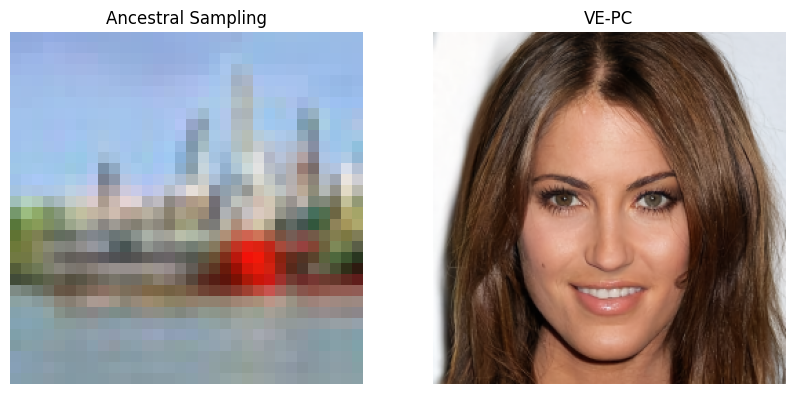

In [4]:
#| echo: true
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(ancestral_image)
axs[0].set_title("Ancestral Sampling")
axs[1].imshow(pc_ve_image)
axs[1].set_title("VE-PC")

for ax in axs:
    ax.axis("off")
plt.show()